In [6]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import skimage as ski
import xarray as xr
import sys

sys.path.append("..")  # Adds higher directory to python modules path.
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

import gaussoptfuncs
from numba import jit

In [8]:
data = pd.read_csv(
    "/home/jbeckwith/Documents/pCloud/Job Applications/URF/2025/ResearchProposal/Figures/PD_Patients.csv",
    header=None,
)
data

,0,1
0,1990.153290,3.352900
1,1990.333946,3.384935
2,1990.543743,3.423933
3,1990.753533,3.458753
4,1990.963321,3.492180
...,...,...
285,2049.444197,24.867413
286,2049.654137,24.992764
287,2049.864004,25.073546
288,2050.065914,25.147365


In [11]:
data_pre = data[data.values[:, 0] < 2020]
data_post = data[data.values[:, 0] >= 2020]

In [13]:
data_pre

,0,1
0,1990.153290,3.352900
1,1990.333946,3.384935
2,1990.543743,3.423933
3,1990.753533,3.458753
4,1990.963321,3.492180
...,...,...
138,2019.080064,11.098236
139,2019.289959,11.195732
140,2019.499841,11.286264
141,2019.709728,11.379581


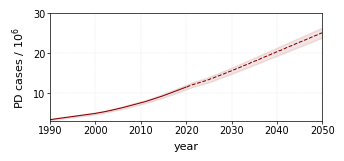

In [26]:
fig, axs = plotter.one_column_plot(height=1.5)

axs = plotter.line_error_plot(
    axs=axs,
    x=data_pre.values[:, 0],
    y=data_pre.values[:, 1],
    yerror=data_pre.values[:, 1] * 0.05,
    color="darkred",
    alpha=0.1,
)

axs = plotter.line_error_plot(
    axs=axs,
    x=data_post.values[:, 0],
    y=data_post.values[:, 1],
    yerror=data_post.values[:, 1] * 0.05,
    color="darkred",
    alpha=0.1,
    ls="--",
    xaxislabel="year",
    yaxislabel=r"PD cases / 10$^6$",
)


axs.set_xlim([1990, 2050])
axs.set_ylim([3, 30])

plt.savefig(
    "/home/jbeckwith/Documents/pCloud/Job Applications/URF/2025/ResearchProposal/Figures/PD_Cases.svg",
    dpi=600,
    format="svg",
)

In [20]:
test = gaussoptfuncs.gaussian_unscaled_model(
    x=x,
    array_tofill=np.zeros((12, 12), dtype=np.float32),
    x0=x0[0],
    y0=y0[0],
    sigma=sigma_psf,
    size=12,
)

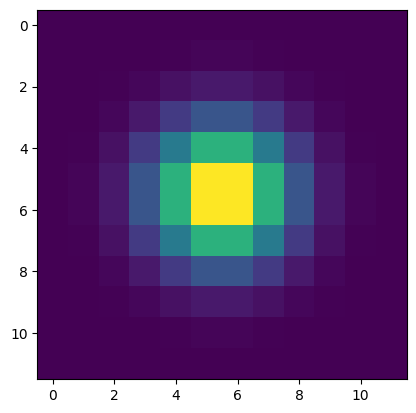

In [21]:
plt.imshow(test)

In [3]:
g2D_PSF = PSF.gaussian2d_PSF(
    x, sigma_psf, x0, y0, n_photons=n_photons, bitdepth=bitdepth
)

In [4]:
np.sum(g2D_PSF)

399.99994

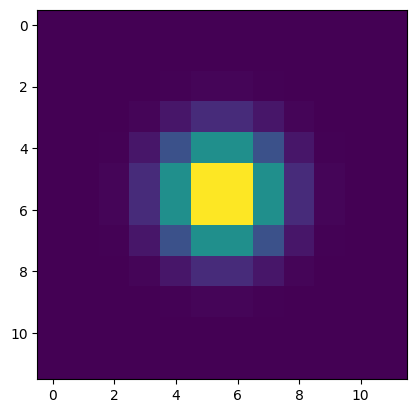

In [5]:
plt.imshow(g2D_PSF)

In [ ]:
n_photoelectrons = PSF.gen_photoelectrons(g2D_PSF.astype(np.uint16), 0.95)

In [ ]:
%timeit PSF.gaussian2d_PSF(x, sigma_psf, x0, y0, n_photons=n_photons, bitdepth=bitdepth)

In [ ]:
%timeit PSF.gen_photons_hitting_detector(n_photoelectrons, 0.4)

In [ ]:
%timeit PSF.gen_photons_hitting_detector_array(n_photoelectrons, 0.4)

In [ ]:
data_folder = "/home/jbeckwith/Downloads/Bfu/"

In [ ]:
files = os.listdir(data_folder)
files = np.sort([x for x in files if "17" in x])

In [ ]:
files

In [ ]:
bin_image_3 = ski.io.imread(os.path.join(data_folder, files[0]))
plt.imshow(bin_image_3)

In [ ]:
bin_image_0 = ski.io.imread(os.path.join(data_folder, files[0]))[:, 1100:1550]
bin_image_1 = ski.io.imread(os.path.join(data_folder, files[1]))[:1000, 700:1000]
bin_image_2 = ski.io.imread(os.path.join(data_folder, files[2]))[:, 100:1000]

In [ ]:
from skimage import feature
from skimage.color import rgb2gray, gray2rgb

In [ ]:
from skimage.filters import gaussian

In [ ]:
def bimages(bimage):
    blur = gaussian(rgb2gray(bimage), 5)
    edges = feature.canny(rgb2gray(bimage), sigma=2)
    bin_fft = np.fft.fftshift(np.fft.fft2(rgb2gray(bimage)))
    return blur, edges, bin_fft

In [ ]:
np.log10(bin_fft)

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=4, widthratio=[1, 1, 1, 1])

blur, edges, bin_fft = bimages(bin_image_0)

axs[0].imshow(bin_image_0)
axs[0].set_axis_off()

axs[1] = plotter.image_plot(
    axs=axs[1], data=blur[::-1], scalebarlabel="", scalebarsize=0, cbar="off"
)
axs[1].set_axis_off()

axs[2] = plotter.image_plot(
    axs=axs[2],
    data=1 * edges[::-1],
    vmin=0,
    vmax=1,
    scalebarlabel="",
    scalebarsize=0,
    cbar="off",
    cmap="pink",
)
axs[2].set_axis_off()

axs[3] = plotter.image_plot(
    axs=axs[3],
    data=np.real(np.log10(bin_fft)),
    scalebarlabel="",
    scalebarsize=0,
    cbar="off",
)
axs[3].set_axis_off()

plt.tight_layout()

plt.savefig("Bin_0.svg", dpi=1200, format="svg")

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=4, widthratio=[1, 1, 1, 1])

blur, edges, bin_fft = bimages(bin_image_1)

axs[0].imshow(bin_image_1)
axs[0].set_axis_off()

axs[1] = plotter.image_plot(
    axs=axs[1], data=blur[::-1], scalebarlabel="", scalebarsize=0, cbar="off"
)
axs[1].set_axis_off()

axs[2] = plotter.image_plot(
    axs=axs[2],
    data=1 * edges[::-1],
    vmin=0,
    vmax=1,
    scalebarlabel="",
    scalebarsize=0,
    cbar="off",
    cmap="pink",
)
axs[2].set_axis_off()

axs[3] = plotter.image_plot(
    axs=axs[3],
    data=np.real(np.log10(bin_fft)),
    scalebarlabel="",
    scalebarsize=0,
    cbar="off",
)
axs[3].set_axis_off()

plt.tight_layout()

plt.savefig("Bin_1.svg", dpi=1200, format="svg")

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=4, widthratio=[1, 1, 1, 1])

blur, edges, bin_fft = bimages(bin_image_2)

axs[0].imshow(bin_image_2)
axs[0].set_axis_off()

axs[1] = plotter.image_plot(
    axs=axs[1], data=blur[::-1], scalebarlabel="", scalebarsize=0, cbar="off"
)
axs[1].set_axis_off()

axs[2] = plotter.image_plot(
    axs=axs[2],
    data=1 * edges[::-1],
    vmin=0,
    vmax=1,
    scalebarlabel="",
    scalebarsize=0,
    cbar="off",
    cmap="pink",
)
axs[2].set_axis_off()

axs[3] = plotter.image_plot(
    axs=axs[3],
    data=np.real(np.log10(bin_fft)),
    scalebarlabel="",
    scalebarsize=0,
    cbar="off",
)
axs[3].set_axis_off()

plt.tight_layout()

plt.savefig("Bin_2.svg", dpi=1200, format="svg")

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=4, widthratio=[1, 1, 1, 1])

blur, edges, bin_fft = bimages(bin_image_3)

axs[0].imshow(bin_image_3)
axs[0].set_axis_off()

axs[1] = plotter.image_plot(
    axs=axs[1], data=blur[::-1], scalebarlabel="", scalebarsize=0, cbar="off"
)
axs[1].set_axis_off()

axs[2] = plotter.image_plot(
    axs=axs[2],
    data=1 * edges[::-1],
    vmin=0,
    vmax=1,
    scalebarlabel="",
    scalebarsize=0,
    cbar="off",
    cmap="pink",
)
axs[2].set_axis_off()

axs[3] = plotter.image_plot(
    axs=axs[3],
    data=np.real(np.log10(bin_fft)),
    scalebarlabel="",
    scalebarsize=0,
    cbar="off",
)
axs[3].set_axis_off()

plt.tight_layout()

plt.savefig("Bin_5.svg", dpi=1200, format="svg")

In [ ]:
%timeit I_AF.WLS_model(params, data, masks)

In [ ]:
%timeit I_AF.WLS_model(params, data, masks)

In [ ]:
A = I_AF.WLS_model(params, data, masks)
B = I_AF.WLS_model(params, data, masks)
plt.imshow(A - B)
plt.colorbar()

In [ ]:
X, Y = np.indices(data.shape)

In [ ]:
def gaussian_model(x, y, xc, yc, A, sigma, b):
    """
    function to simulate a gaussian psf.

    Args:
        xc (float): centroid position in x.
        yc (float): centroid position in y.
        A (float): amplitude.
        sigma (float): width
        b (float): background

    Returns:
        data (numpy.ndarray): simulated 2D gaussian.
    """
    x_scaled = (xc - x) / sigma
    y_scaled = (yc - y) / sigma
    exponent = -0.5 * (np.square(x_scaled) + np.square(y_scaled))
    return A * np.exp(exponent) + b

In [ ]:
def gaussian_model_lambdafunc(xc, yc, A, sigma, b):
    """
    lambda function to simulate a gaussian psf.

    Args:
        xc (float): centroid position in x.
        yc (float): centroid position in y.
        A (float): amplitude.
        sigma (float): width
        b (float): background

    Returns:
        lambda function (numpy.ndarray): simulated 2D gaussian.
    """
    return lambda x, y: A * np.exp(
        -(((xc - x) / sigma) ** 2 + ((yc - y) / sigma) ** 2) / 2
    ) + np.sqrt(np.square(b))

In [ ]:
import pandas as pd

df = pd.DataFrame([[1, 1.0, "a"]], columns=["x", "y", "z"])

df.to_hdf("test.h5", key="data", format="table")

reread = pd.read_hdf("test.h5")

In [ ]:
reread

In [ ]:
df.to_hdf("test.h5", key="data", append=True, mode="r+", format="table")

In [ ]:
reread = pd.read_hdf("test.h5")

In [ ]:
from concurrent import futures
import numpy as np

In [ ]:
def test_function(a, b, c):
    return np.full(5, a + c), np.full(6, b)

In [ ]:
values = np.arange(10)

In [ ]:
executor = futures.ProcessPoolExecutor(5)
fs = []
for i in np.arange(10):
    fs.append(executor.submit(test_function, values[i], values[i], 1))

In [ ]:
results = [_.result()[1] for _ in fs]

In [ ]:
results